In this notebook, we conduct a deep dive into our final model - the Poisson Regression model.

In [2]:
library(tidyverse)
library(tis)
library(baseballr)
library(hoopR)
library(MASS)
library(glmnet)
library(mpath)
library(glmmTMB)
library(Matrix)
library(lmtest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘tis’


The following objects are masked from ‘package:lubridate’:

    day, hms, month, period, POSIXct, quarter, today, year, ymd


The following object is masked from ‘package:dplyr’:

    between



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glm

In [3]:
setwd('..')
getwd()

df <- read_csv("./data/final-dataset.csv")

# Split into Training and Testing sets. Treat hour as a factor.
train <- df %>% filter(year(date) < 2025) %>% mutate(hour = as_factor(hour))
test <- df %>% filter(year(date) == 2025) %>% mutate(hour = as_factor(hour))

# Train Model
poisson_lm <- glm(ridership ~ ., data = train[, -c(1)], family = poisson(link = "log"))

y_train <- train$ridership
y_test <- test$ridership

eval_preds <- function(preds, actual) {
  mse  <- mean((actual - preds)^2)
  rmse <- sqrt(mse)
  list(mse = mse, rmse = rmse)
}

# Prediction on Test Set
preds_poisson  <- predict(poisson_lm, newdata = test, type = "response")
result_poisson <- eval_preds(preds_poisson, y_test)

[1] "/accounts/masters/ben_khothsombath/repos/230A-final-project"

Rows: 1130841 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): destination, day, season
dbl  (2): hour, ridership
lgl  (9): destination_green, destination_red, destination_yellow, destinatio...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ERROR: Error in eval_preds(preds_poisson, y_test): could not find function "eval_preds"


Let's also train the Poisson regression on the full model.

In [4]:
full <- df %>% mutate(hour = as_factor(hour))

poisson_full <- glm(ridership ~ ., data = full[, -c(1)], family = poisson(link = "log"))

Let's look at some model diagnostics of the full model.

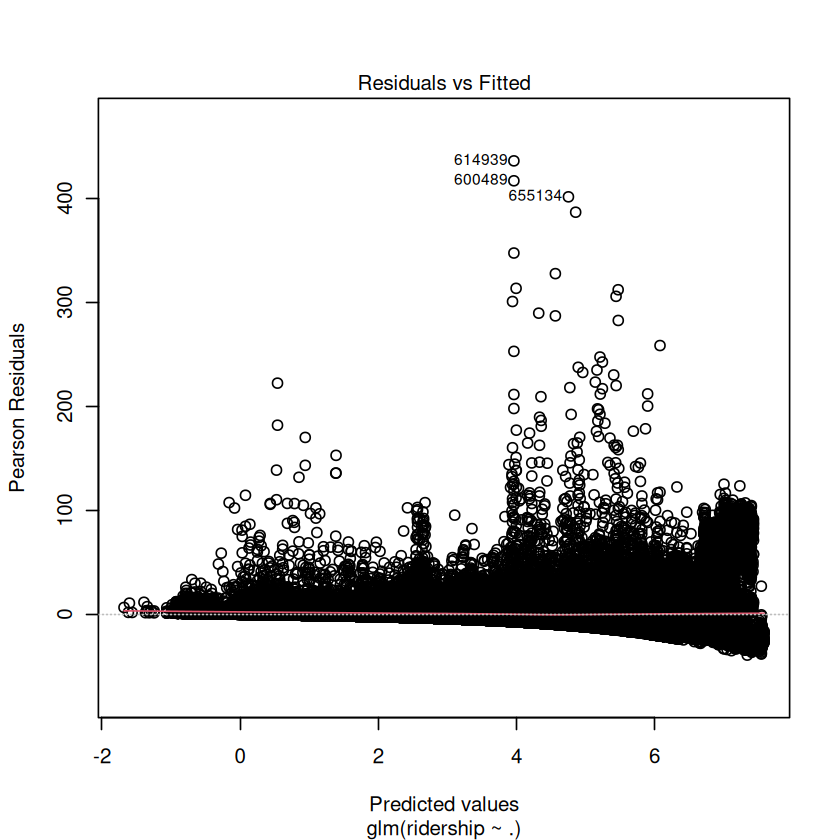

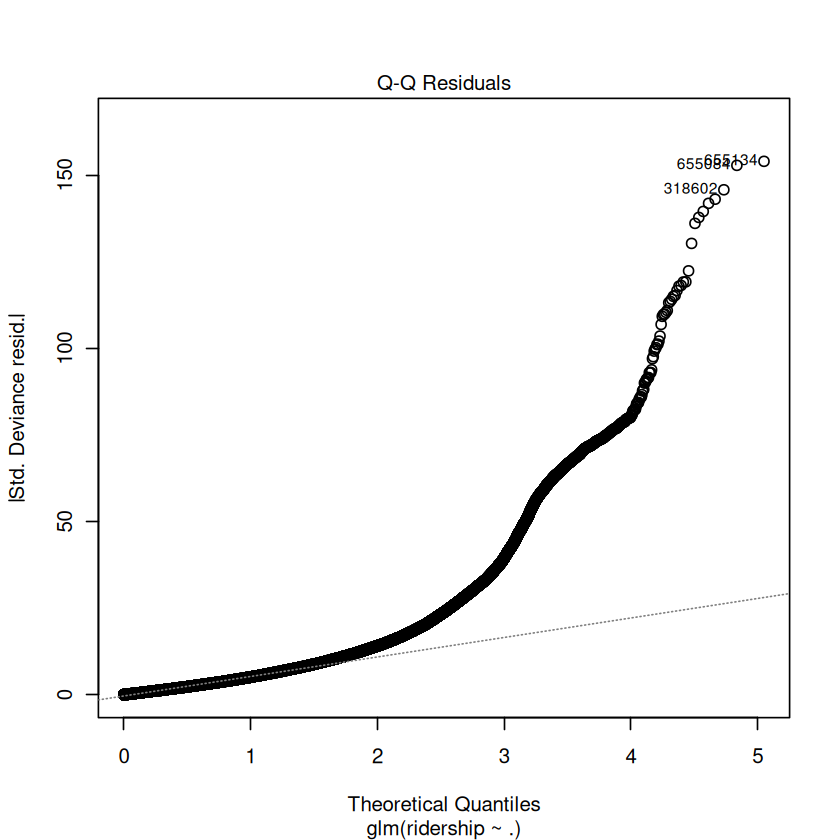

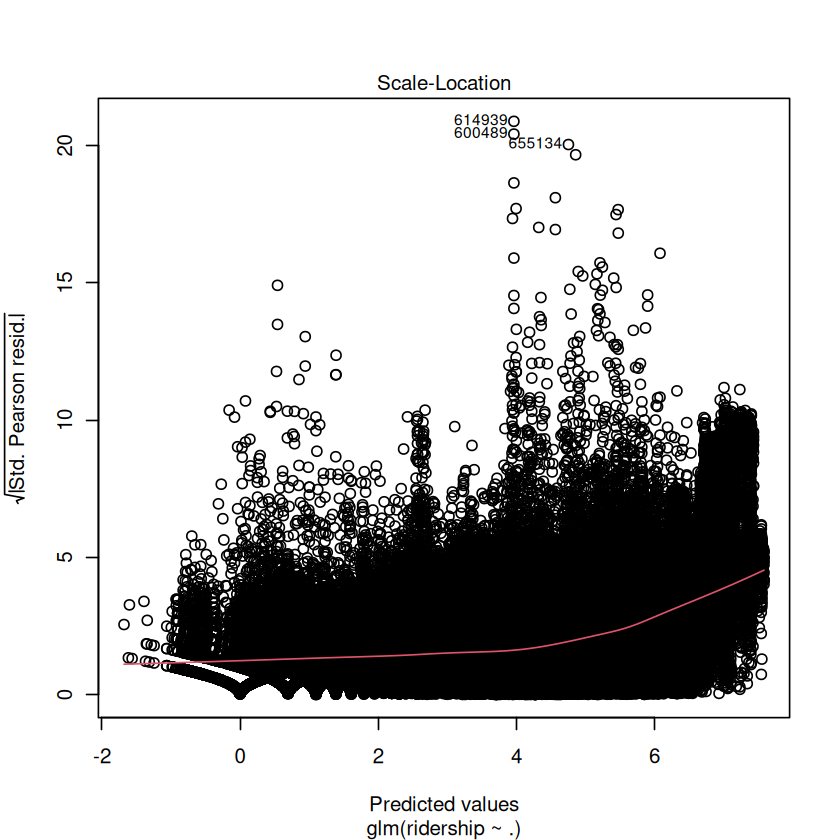

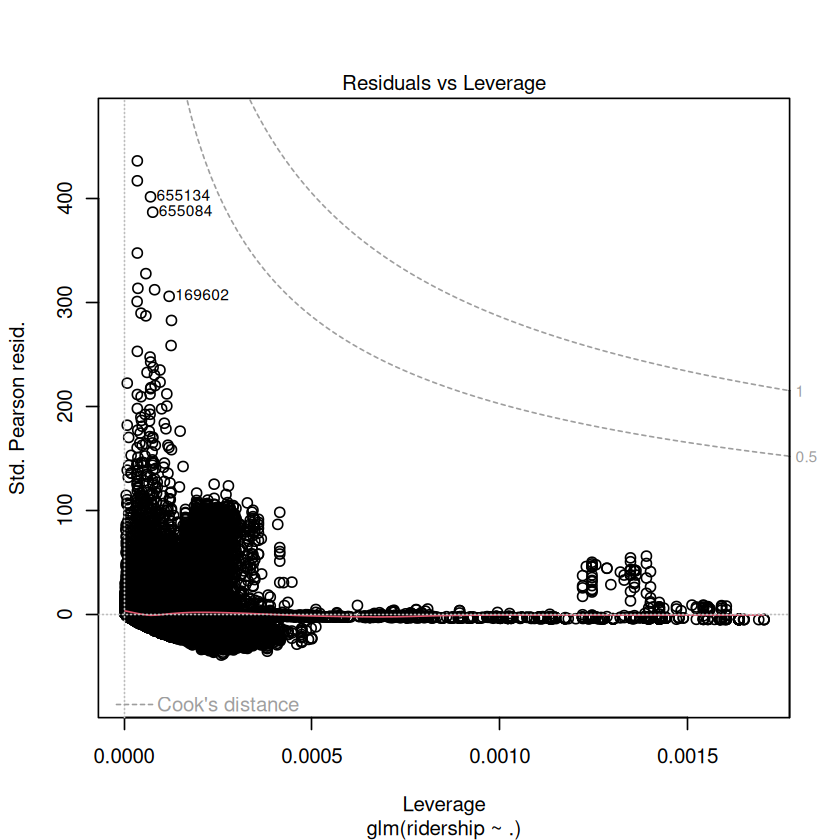

In [5]:
plot(poisson_full)

In [6]:
summary(poisson_full)


Call:
glm(formula = ridership ~ ., family = poisson(link = "log"), 
    data = full[, -c(1)])

Coefficients: (5 not defined because of singularities)
                         Estimate Std. Error  z value Pr(>|z|)    
(Intercept)             3.1570266  0.0010472  3014.65   <2e-16 ***
hour1                  -1.4515209  0.0022159  -655.05   <2e-16 ***
hour2                  -1.6098226  0.0077397  -208.00   <2e-16 ***
hour3                  -2.2286506  0.0098376  -226.54   <2e-16 ***
hour4                  -2.2231140  0.0044330  -501.49   <2e-16 ***
hour5                   0.3730962  0.0012000   310.90   <2e-16 ***
hour6                   1.4625067  0.0009981  1465.29   <2e-16 ***
hour7                   2.1207093  0.0009450  2244.16   <2e-16 ***
hour8                   2.4651285  0.0009291  2653.29   <2e-16 ***
hour9                   2.1732806  0.0009412  2309.00   <2e-16 ***
hour10                  1.7495837  0.0009662  1810.80   <2e-16 ***
hour11                  1.6450352  0.0009740 

Let's do a deeper dive into some analysis. One of the things that the plot above shows is that we get the highest standardized pearson residuals at low-leverage points. Because the model consists of many indicator functions, it's possible that this suggests misspecification in the model. That is, we're likely missing variables that can predict ridership. To name a few examples, we don't consider days where protests are occuring, the holiday variable is binary, rather than having levels for different holidays, and some Warriors games are bigger than others.

Let's take a look at which destination-hour combinations have the largest residuals and see if they share any characteristics.

In [8]:
pearson_resid <- residuals(poisson_full, type = "pearson")
leverage <- hatvalues(poisson_full)

resid_df <- tibble(
    destination = full$destination,
    hour = full$hour,
    day = full$day,
    is_holiday = full$is_holiday,
    fitted = fitted(poisson_full),
    pearson_resid = pearson_resid,
    leverage = leverage,
    abs_resid = abs(pearson_resid)
)

resid_df %>%
    arrange(desc(abs_resid)) %>%
    filter(leverage < median(leverage)) %>%
    head(20)

destination,hour,day,is_holiday,fitted,pearson_resid,leverage,abs_resid
<chr>,<fct>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
COLS,12,sunday,FALSE,52.671733,435.8685,3.548985e-05,435.8685
COLS,12,sunday,FALSE,52.671733,416.7160,3.548985e-05,416.7160
COLS,12,sunday,FALSE,52.671733,347.2708,3.548985e-05,347.2708
COLS,15,saturday,FALSE,96.026364,327.4695,5.821666e-05,327.4695
COLS,12,sunday,FALSE,54.379865,313.3354,3.696122e-05,313.3354
COLS,11,sunday,FALSE,51.629637,300.6621,3.494490e-05,300.6621
LAKE,12,saturday,FALSE,75.463361,289.4609,4.527820e-05,289.4609
COLS,15,saturday,FALSE,96.026364,286.8544,5.821666e-05,286.8544
COLS,12,sunday,FALSE,52.671733,252.7483,3.548985e-05,252.7483


Interestingly, many of these high pearson residual points are Weekends at colliseum, suggesting that perhaps these hours, there is something going on that we are missing. It could also be that we should have included an interaction for coliseum x sports games.

Next, let's do a stratified prediction performance. Let's look at some splits

* weekday vs weekend
* peak vs off-peak horus

and see how the test set performed on these splits.

In [10]:
test_annotated <- test %>%
    mutate(
        pred = preds_poisson,
        residual = ridership - pred,
        sq_error = residual^2,
        period = case_when(
            as.integer(as.character(hour)) %in% 7:9 ~ "AM Peak",
            as.integer(as.character(hour)) %in% 16:18 ~ "PM Peak",
            TRUE ~ "Off-Peak"
        ),
        day_type = ifelse(day %in% c("saturday", "sunday"), "weekend", "weekday")
    )

test_annotated %>%
    group_by(day_type, period) %>%
    summarise(
        RMSE = sqrt(mean(sq_error)),
        MAE = mean(abs(residual)),
        n = n()
    ) %>%
    arrange(desc(n))

`summarise()` has grouped output by 'day_type'. You can override using the
`.groups` argument.


day_type,period,RMSE,MAE,n
<chr>,<chr>,<dbl>,<dbl>,<int>
weekday,Off-Peak,84.77047,39.40341,197085
weekend,Off-Peak,99.59184,41.20984,71202
weekday,PM Peak,240.82702,157.38524,39109
weekday,AM Peak,444.73833,170.28702,38658
weekend,PM Peak,111.55327,49.33146,15575
weekend,AM Peak,107.92942,74.85918,14465


We see the largest errors occuring for weekdays during peak hours. Perhaps we should have included an interaction term for the hour x day of week. The hour factor assumes that ridership on weekdays and weekends are the same, when they aren't!

Now, let's look at a rootogram to compare the distributions of predicted vs actual ridership.

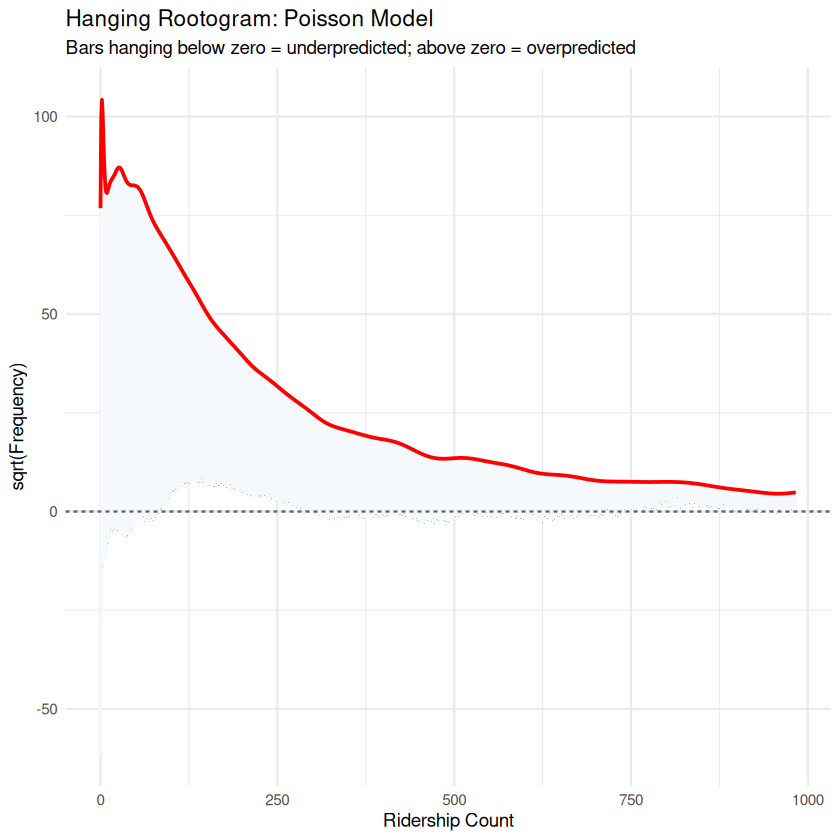

In [16]:
# Observed Counts and model-fitted values
observed <- full$ridership
expected <- fitted(poisson_full)

# Build observed and expected frequency tables over count values
max_count <- quantile(observed, 0.99)  # trim extreme tail for readability
count_vals <- 0:max_count

obs_freq <- tabulate(observed + 1)[1:(max_count + 1)]
obs_freq[is.na(obs_freq)] <- 0

# Expected frequencies: sum predicted probabilities across all observations
# For Poisson, P(Y=k | mu_i) = dpois(k, mu_i)
exp_freq <- sapply(count_vals, function(k) sum(dpois(k, lambda = expected)))

rootogram_df <- tibble(
  count = count_vals,
  observed = obs_freq,
  expected = exp_freq,
  sqrt_obs = sqrt(obs_freq),
  sqrt_exp = sqrt(exp_freq),
  # "hanging": bar bottom is sqrt_exp - sqrt_obs, top is sqrt_exp
  bar_top = sqrt_exp,
  bar_bot = sqrt_exp - sqrt_obs
)

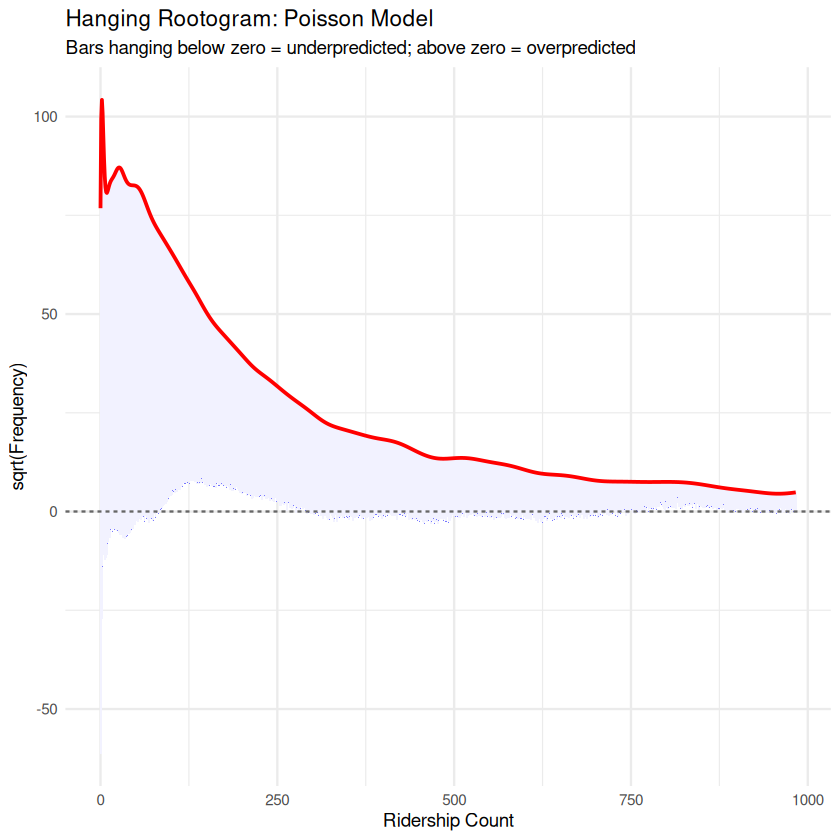

In [17]:
ggplot(rootogram_df, aes(x = count)) +
  geom_rect(
    aes(xmin = count - 0.45, xmax = count + 0.45,
        ymin = bar_bot, ymax = bar_top),
    fill = "blue", color = "white", linewidth = 0.2
  ) +
  geom_line(aes(y = sqrt_exp), color = "red", linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray40") +
  labs(
    title = "Hanging Rootogram: Poisson Model",
    subtitle = "Bars hanging below zero = underpredicted; above zero = overpredicted",
    x = "Ridership Count",
    y = "sqrt(Frequency)"
  ) +
  theme_minimal()

From the rootogram above, we see that we tend to overpredict ridership for values between ~100-250, but underpredict values when ridership is between ~0-125 and ~250-750.

Now, let's look at the distribution of residuals over time to see if the model degrades on any particular time in 2025.

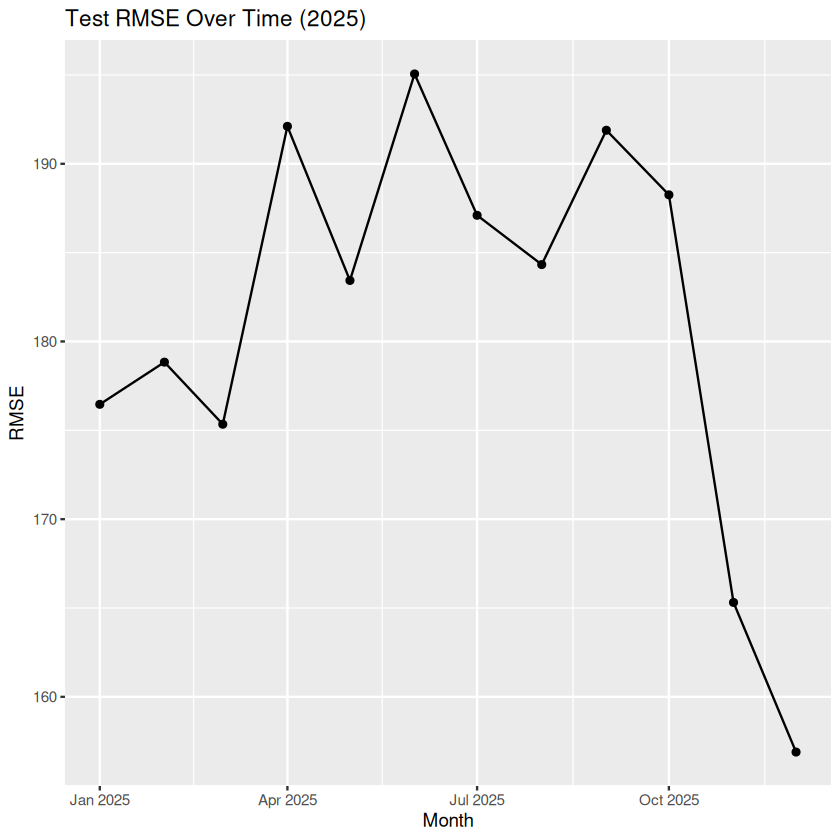

In [18]:
test %>%
    mutate(
        pred = preds_poisson,
        sq_error = (ridership - pred)^2,
        month = floor_date(date, "month")
    ) %>%
    group_by(month) %>%
    summarise(RMSE = sqrt(mean(sq_error))) %>%
    ggplot(aes(x = month, y = RMSE)) +
    geom_line() + geom_point() +
    labs(title = "Test RMSE Over Time (2025)", x = "Month", y = "RMSE")

RMSE peaks for the middle of the year, but is lower for the winter months.

Let's check for overdispersion by comparing against the negative binomial model.

In [20]:
nb_lm <- glm.nb(ridership ~ ., data = train[, -c(1)])

lrtest(nb_lm, poisson_lm)
nb_lm$theta

Warning message in modelUpdate(objects[[i - 1]], objects[[i]]):
“original model was of class "negbin", updated model is of class "glm"”


,#Df,LogLik,Df,Chisq,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,83,-3810795,NA,NA,NA
2,82,-20608498,-1,33595405,0


[1] 3.185015

From the likelihood ratio test, we see that the chi-squared is $3.3 \times 10^7$, suggesting that the NB model fits the training data dramatically better than that of the Poisson regression in terms of likelihood. However, our Poisson had a better test MSE despite the data being overdispersed. The reason for this is that overdispersion affects the variance of the distribution, not the mean, while MSE only cares about the mean. In other words, the NB model's extra flexibility in modeling variance didn't translate to creating better predictions on the test set. Even though the Poisson model is misspecified (in more ways than one), for prediction, that misspecification doesn't necessarily hurt.

Let's try rebuilding another model, this time, we'll include hour x day as an interaction term.

In [21]:
poisson_lm2 <- glm(ridership ~ destination + hour*day + is_holiday + is_giants_home + is_as_home + warriors_at_chase + season, data = train[, -c(1)], family = poisson(link = "log"))
summary(poisson_lm2)


Call:
glm(formula = ridership ~ destination + hour * day + is_holiday + 
    is_giants_home + is_as_home + warriors_at_chase + season, 
    family = poisson(link = "log"), data = train[, -c(1)])

Coefficients:
                        Estimate Std. Error   z value Pr(>|z|)    
(Intercept)            3.8703854  0.0025282  1530.857  < 2e-16 ***
destination16TH        0.2203001  0.0007967   276.523  < 2e-16 ***
destination19TH       -0.0195348  0.0008437   -23.153  < 2e-16 ***
destination24TH        0.1794422  0.0008041   223.166  < 2e-16 ***
destinationANTC       -1.0015915  0.0011477  -872.665  < 2e-16 ***
destinationASHB       -0.8803469  0.0010966  -802.833  < 2e-16 ***
destinationBALB       -0.1903038  0.0008826  -215.614  < 2e-16 ***
destinationBAYF       -0.6100864  0.0010000  -610.071  < 2e-16 ***
destinationBERY       -1.1188810  0.0011954  -935.992  < 2e-16 ***
destinationCAST       -1.3802434  0.0013246 -1042.041  < 2e-16 ***
destinationCIVC        0.6323479  0.0007344   861.05

ERROR: Error in eval_preds(preds_poisson2, y_test): could not find function "eval_preds"


In [25]:
# Prediction on Test Set
preds_poisson2  <- predict(poisson_lm2, newdata = test, type = "response")
result_poisson2 <- eval_preds(preds_poisson2, y_test)

result_poisson2

$mse
[1] 30254.29

$rmse
[1] 173.9376

From this, we see that including those interaction terms helps lower the MSE! Let's include it in our final model.

In [26]:
poisson_final <- glm(ridership ~ destination + hour*day + is_holiday + is_giants_home + is_as_home + warriors_at_chase + season, data = full[, -c(1)], family = poisson(link = "log"))
summary(poisson_final)


Call:
glm(formula = ridership ~ destination + hour * day + is_holiday + 
    is_giants_home + is_as_home + warriors_at_chase + season, 
    family = poisson(link = "log"), data = full[, -c(1)])

Coefficients:
                        Estimate Std. Error   z value Pr(>|z|)    
(Intercept)            3.9522303  0.0019885  1987.563   <2e-16 ***
destination16TH        0.1922051  0.0006407   299.981   <2e-16 ***
destination19TH       -0.0346335  0.0006769   -51.168   <2e-16 ***
destination24TH        0.1513493  0.0006468   234.008   <2e-16 ***
destinationANTC       -1.0238412  0.0009256 -1106.161   <2e-16 ***
destinationASHB       -0.8994472  0.0008823 -1019.487   <2e-16 ***
destinationBALB       -0.2102213  0.0007091  -296.466   <2e-16 ***
destinationBAYF       -0.6287184  0.0008043  -781.725   <2e-16 ***
destinationBERY       -1.1321055  0.0009607 -1178.460   <2e-16 ***
destinationCAST       -1.3902958  0.0010634 -1307.458   <2e-16 ***
destinationCIVC        0.6189287  0.0005883  1052.115